# Producto 1er Parcial
**Materia:** Extracción de Base de Datos  
**Alumno:** Martínez Rivera Brenda Alexandra  
**Fecha:** 10 Junio 2026  

## Instalacion y configuración

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

In [2]:
# SDV para generación de datos sintéticos
import sdv
import sdmetrics
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer
from sdmetrics.reports.single_table import QualityReport

print("SDV version:", sdv.__version__)
print("Librerías importadas correctamente ✓")

SDV version: 1.37.0
Librerías importadas correctamente ✓


In [3]:
from sqlalchemy import create_engine, text

In [8]:
pip install psycopg2-binary

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.8 MB 3.4 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.8 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 3.7 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


### Conexión a PostgreSQL

In [4]:
# Configuración de la conexión a PostgreSQL
DB_USER     = "postgres"
DB_PASSWORD = "123456"
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "dw_ventas"

# Crear engine con SQLAlchemy
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Probar conexión
with engine.connect() as conn:
    resultado = conn.execute(text("SELECT version();"))
    version = resultado.fetchone()[0]
    print("Conexión exitosa ✓")
    print("PostgreSQL:", version)

Conexión exitosa ✓
PostgreSQL: PostgreSQL 15.3, compiled by Visual C++ build 1914, 64-bit


## DISEÑO DEL MODELO DIMENSIONAL (Star Schema)

In [5]:
# tablas del Data Warehouse en PostgreSQL
ddl_script = """
-- Dimensión Clientes
CREATE TABLE IF NOT EXISTS dim_cliente (
    cliente_id   SERIAL PRIMARY KEY,
    nombre       VARCHAR(100),
    edad         INT,
    ciudad       VARCHAR(80),
    region       VARCHAR(60),
    segmento     VARCHAR(40)
);

-- Dimensión Productos
CREATE TABLE IF NOT EXISTS dim_producto (
    producto_id  SERIAL PRIMARY KEY,
    nombre       VARCHAR(120),
    categoria    VARCHAR(60),
    precio_unit  NUMERIC(10,2)
);

-- Dimensión Tiempo
CREATE TABLE IF NOT EXISTS dim_tiempo (
    tiempo_id    SERIAL PRIMARY KEY,
    fecha        DATE,
    anio         INT,
    mes          INT,
    trimestre    INT,
    dia_semana   VARCHAR(20)
);

-- Dimensión Región
CREATE TABLE IF NOT EXISTS dim_region (
    region_id    SERIAL PRIMARY KEY,
    nombre       VARCHAR(60),
    estado       VARCHAR(60),
    pais         VARCHAR(40)
);

-- Tabla de Hechos: Ventas
CREATE TABLE IF NOT EXISTS fact_ventas (
    venta_id     SERIAL PRIMARY KEY,
    cliente_id   INT REFERENCES dim_cliente(cliente_id),
    producto_id  INT REFERENCES dim_producto(producto_id),
    tiempo_id    INT REFERENCES dim_tiempo(tiempo_id),
    region_id    INT REFERENCES dim_region(region_id),
    cantidad     INT,
    monto_total  NUMERIC(12,2),
    descuento    NUMERIC(5,2)
);
"""

with engine.begin() as conn:
    conn.execute(text(ddl_script))

print("Tablas creadas exitosamente en PostgreSQL ✓")

Tablas creadas exitosamente en PostgreSQL ✓



## CARGA DE DATOS (ETL)

In [7]:
# DataFrame base de clientes
dfClientes = pd.DataFrame(
    {
        "cliente_id":  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "nombre":      ["Ana Pérez", "Luis Martínez", "María López", "Carlos Ruiz",
                        "Sandra Torres", "Jorge Díaz", "Elena Vega", "Miguel Reyes",
                        "Lucía Flores", "Pablo Morales"],
        "edad":        [23, 33, 43, 28, 53, 56, 43, 56, 65, 40],
        "ciudad":      ["Tuxtepec", "Oaxaca", "Veracruz", "Córdoba",
                        "Puebla", "CDMX", "Guadalajara", "Monterrey",
                        "Mérida", "Tijuana"],
        "region":      ["Sur", "Sur", "Sur", "Sur",
                        "Centro", "Centro", "Occidente", "Norte",
                        "Sureste", "Norte"],
        "segmento":    ["Minorista", "Mayorista", "Minorista", "Mayorista",
                        "Minorista", "Corporativo", "Corporativo", "Mayorista",
                        "Minorista", "Corporativo"]
    }
)

In [8]:
dfClientes.head()

,cliente_id,nombre,edad,ciudad,region,segmento
0,1,Ana Pérez,23,Tuxtepec,Sur,Minorista
1,2,Luis Martínez,33,Oaxaca,Sur,Mayorista
2,3,María López,43,Veracruz,Sur,Minorista
3,4,Carlos Ruiz,28,Córdoba,Sur,Mayorista
4,5,Sandra Torres,53,Puebla,Centro,Minorista


In [9]:
# DataFrame base de productos
dfProductos = pd.DataFrame(
    {
        "producto_id":  [1, 2, 3, 4, 5, 6, 7, 8],
        "nombre":       ["Laptop HP", "Monitor LG", "Teclado Logitech", "Mouse Inalámbrico",
                         "Tablet Samsung", "Auriculares Sony", "Webcam Logitech", "Disco SSD 1TB"],
        "categoria":    ["Computadoras", "Periféricos", "Periféricos", "Periféricos",
                         "Móviles", "Audio", "Periféricos", "Almacenamiento"],
        "precio_unit":  [15000.00, 4500.00, 850.00, 350.00,
                         9000.00, 1200.00, 780.00, 1800.00]
    }
)

In [10]:
dfProductos.head()

,producto_id,nombre,categoria,precio_unit
0,1,Laptop HP,Computadoras,15000.0
1,2,Monitor LG,Periféricos,4500.0
2,3,Teclado Logitech,Periféricos,850.0
3,4,Mouse Inalámbrico,Periféricos,350.0
4,5,Tablet Samsung,Móviles,9000.0


In [11]:
# DataFrame de dimensión Tiempo (últimos 12 meses)
fechas = pd.date_range(start="2024-01-01", end="2024-12-31", freq="ME")
dfTiempo = pd.DataFrame(
    {
        "tiempo_id":  range(1, len(fechas) + 1),
        "fecha":      fechas,
        "anio":       fechas.year,
        "mes":        fechas.month,
        "trimestre":  fechas.quarter,
        "dia_semana": fechas.day_name()
    }
)
dfTiempo.head()

,tiempo_id,fecha,anio,mes,trimestre,dia_semana
0,1,2024-01-31,2024,1,1,Wednesday
1,2,2024-02-29,2024,2,1,Thursday
2,3,2024-03-31,2024,3,1,Sunday
3,4,2024-04-30,2024,4,2,Tuesday
4,5,2024-05-31,2024,5,2,Friday


In [12]:
# DataFrame de dimensión Región
dfRegion = pd.DataFrame(
    {
        "region_id": [1, 2, 3, 4, 5],
        "nombre":    ["Sur", "Centro", "Occidente", "Norte", "Sureste"],
        "estado":    ["Oaxaca", "CDMX", "Jalisco", "Nuevo León", "Yucatán"],
        "pais":      ["México"] * 5
    }
)
dfRegion

,region_id,nombre,estado,pais
0,1,Sur,Oaxaca,México
1,2,Centro,CDMX,México
2,3,Occidente,Jalisco,México
3,4,Norte,Nuevo León,México
4,5,Sureste,Yucatán,México


## Generación de Datos Sintéticos con SDV 

In [13]:
# Crear metadata para SDV 
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(
    data = dfClientes
)
metadata.to_dict()

{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'columns': {'cliente_id': {'sdtype': 'id'},
  'nombre': {'sdtype': 'categorical'},
  'edad': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'},
  'region': {'sdtype': 'categorical'},
  'segmento': {'sdtype': 'categorical'}},
 'primary_key': 'cliente_id'}

In [16]:
# Guardar metadata en archivo JSON 
metadata.save_to_json(
    "dfClientes_metadata_v2.json"
)

In [17]:
# Entrenar el modelo para generar datos sintéticos
synthesizer = GaussianCopulaSynthesizer(
    metadata
)
synthesizer.fit(
    dfClientes
)

C:\Users\brenr\anaconda3\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



In [18]:
# Generar 90 clientes sintéticos
clientes_sinteticos = synthesizer.sample(
    num_rows = 90
)
clientes_sinteticos.head()

,cliente_id,nombre,edad,ciudad,region,segmento
0,16169768,Lucía Flores,49,Tijuana,Centro,Corporativo
1,4918803,María López,36,Córdoba,Sur,Mayorista
2,1900081,Lucía Flores,31,Tijuana,Sur,Corporativo
3,531516,Carlos Ruiz,40,Puebla,Centro,Minorista
4,10211768,Luis Martínez,43,Oaxaca,Occidente,Corporativo


In [19]:
clientes_sinteticos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   cliente_id  90 non-null     int64 
 1   nombre      90 non-null     object
 2   edad        90 non-null     int64 
 3   ciudad      90 non-null     object
 4   region      90 non-null     object
 5   segmento    90 non-null     object
dtypes: int64(2), object(4)
memory usage: 4.3+ KB


In [20]:
clientes_sinteticos.describe(include = "all")

,cliente_id,nombre,edad,ciudad,region,segmento
count,9.000000e+01,90,90.000000,90,90,90
unique,NaN,9,NaN,10,5,3
top,NaN,Luis Martínez,NaN,Oaxaca,Sur,Mayorista
freq,NaN,23,NaN,16,41,34
mean,8.596829e+06,NaN,43.566667,NaN,NaN,NaN
std,4.653282e+06,NaN,12.681979,NaN,NaN,NaN
min,4.660500e+04,NaN,28.000000,NaN,NaN,NaN
25%,5.066923e+06,NaN,31.250000,NaN,NaN,NaN
50%,8.956428e+06,NaN,41.500000,NaN,NaN,NaN
75%,1.266882e+07,NaN,55.750000,NaN,NaN,NaN


In [21]:
# Generar el reporte de calidad 
report = QualityReport()
report.generate(
    real_data = dfClientes,
    synthetic_data = clientes_sinteticos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 6/6 [00:00<00:00, 65.40it/s]|
Column Shapes Score: 85.56%

(2/2) Evaluating Column Pair Trends: |██████████| 15/15 [00:00<00:00, 18.25it/s]|
Column Pair Trends Score: 31.44%

Overall Score (Average): 58.5%



In [22]:
# Combinar clientes reales + sintéticos en un solo DataFrame
dfClientesTotal = pd.concat([dfClientes, clientes_sinteticos], ignore_index=True)
dfClientesTotal = dfClientesTotal.drop_duplicates().reset_index(drop=True)

print(f"Total de clientes para cargar al DW: {len(dfClientesTotal)}")
dfClientesTotal.head()

Total de clientes para cargar al DW: 100


,cliente_id,nombre,edad,ciudad,region,segmento
0,1,Ana Pérez,23,Tuxtepec,Sur,Minorista
1,2,Luis Martínez,33,Oaxaca,Sur,Mayorista
2,3,María López,43,Veracruz,Sur,Minorista
3,4,Carlos Ruiz,28,Córdoba,Sur,Mayorista
4,5,Sandra Torres,53,Puebla,Centro,Minorista


In [23]:
# Generar tabla de hechos: ventas simuladas
random.seed(42)
np.random.seed(42)

n_ventas = 300

dfVentas = pd.DataFrame(
    {
        "venta_id":    range(1, n_ventas + 1),
        "cliente_id":  np.random.randint(1, 11, size=n_ventas),
        "producto_id": np.random.randint(1, 9, size=n_ventas),
        "tiempo_id":   np.random.randint(1, 13, size=n_ventas),
        "region_id":   np.random.randint(1, 6, size=n_ventas),
        "cantidad":    np.random.randint(1, 11, size=n_ventas),
        "descuento":   np.round(np.random.choice([0.0, 0.05, 0.10, 0.15, 0.20], size=n_ventas), 2)
    }
)

# Calcular monto_total: precio_unit * cantidad * (1 - descuento)
precios = dfProductos.set_index("producto_id")["precio_unit"]
dfVentas["monto_total"] = dfVentas.apply(
    lambda row: round(
        precios.loc[row["producto_id"]] * row["cantidad"] * (1 - row["descuento"]), 2
    ), axis=1
)

dfVentas.head()

,venta_id,cliente_id,producto_id,tiempo_id,region_id,cantidad,descuento,monto_total
0,1,7,5,7,1,8,0.00,72000.0
1,2,4,8,5,3,1,0.00,1800.0
2,3,8,5,12,3,1,0.10,8100.0
3,4,5,1,1,3,6,0.20,72000.0
4,5,7,6,7,5,10,0.05,11400.0


In [24]:
dfVentas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   venta_id     300 non-null    int64  
 1   cliente_id   300 non-null    int32  
 2   producto_id  300 non-null    int32  
 3   tiempo_id    300 non-null    int32  
 4   region_id    300 non-null    int32  
 5   cantidad     300 non-null    int32  
 6   descuento    300 non-null    float64
 7   monto_total  300 non-null    float64
dtypes: float64(2), int32(5), int64(1)
memory usage: 13.0 KB


In [25]:
dfVentas.describe(include = "all")

,venta_id,cliente_id,producto_id,tiempo_id,region_id,cantidad,descuento,monto_total
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,4.510000,6.423333,2.973333,5.373333,0.099167,22812.638333
std,86.746758,2.873001,2.338403,3.535409,1.421040,2.939858,0.071704,32370.658273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,297.500000
25%,75.750000,3.000000,2.000000,3.000000,2.000000,3.000000,0.050000,2887.500000
50%,150.500000,5.000000,5.000000,6.000000,3.000000,5.000000,0.100000,7650.000000
75%,225.250000,8.000000,7.000000,10.000000,4.000000,8.000000,0.150000,31500.000000
max,300.000000,10.000000,8.000000,12.000000,5.000000,10.000000,0.200000,150000.000000


## Cargar DataFrames a PostgreSQL con SQLAlchemy

In [26]:
# Cargar tablas de dimensión a PostgreSQL
dfClientes.to_sql("dim_cliente",   engine, if_exists="append", index=False)
dfProductos.to_sql("dim_producto", engine, if_exists="append", index=False)
dfTiempo.to_sql("dim_tiempo",      engine, if_exists="append", index=False)
dfRegion.to_sql("dim_region",      engine, if_exists="append", index=False)

print("Dimensiones cargadas correctamente ")

Dimensiones cargadas correctamente 


In [27]:
# Cargar tabla de hechos
dfVentas.to_sql("fact_ventas", engine, if_exists="append", index=False)

print("Tabla de hechos cargada correctamente ")

Tabla de hechos cargada correctamente 


##  CONSULTAS SQL Y ANÁLISIS CON PANDAS

In [28]:
# Consulta 1: Ventas totales por región
query_region = """
SELECT
    r.nombre       AS region,
    SUM(v.monto_total) AS total_ventas,
    COUNT(v.venta_id)  AS num_transacciones
FROM fact_ventas v
JOIN dim_region r ON v.region_id = r.region_id
GROUP BY r.nombre
ORDER BY total_ventas DESC;
"""

dfVentasRegion = pd.read_sql(query_region, engine)
dfVentasRegion

,region,total_ventas,num_transacciones
0,Occidente,1634727.5,65
1,Sur,1391897.0,63
2,Norte,1364854.0,55
3,Sureste,1328531.5,60
4,Centro,1123781.5,57


In [29]:
# Consulta 2: Productos más vendidos
query_productos = """
SELECT
    p.nombre       AS producto,
    p.categoria    AS categoria,
    SUM(v.cantidad)    AS unidades_vendidas,
    SUM(v.monto_total) AS ingresos_totales
FROM fact_ventas v
JOIN dim_producto p ON v.producto_id = p.producto_id
GROUP BY p.nombre, p.categoria
ORDER BY ingresos_totales DESC;
"""

dfTopProductos = pd.read_sql(query_productos, engine)
dfTopProductos

,producto,categoria,unidades_vendidas,ingresos_totales
0,Laptop HP,Computadoras,229,3064500.0
1,Tablet Samsung,Móviles,229,1838250.0
2,Monitor LG,Periféricos,281,1155150.0
3,Disco SSD 1TB,Almacenamiento,200,328590.0
4,Auriculares Sony,Audio,135,144720.0
5,Webcam Logitech,Periféricos,192,134784.0
6,Teclado Logitech,Periféricos,153,117002.5
7,Mouse Inalámbrico,Periféricos,193,60795.0


In [30]:
# Consulta 3: Ventas por mes (tendencia anual)
query_mes = """
SELECT
    t.mes          AS mes,
    t.trimestre    AS trimestre,
    SUM(v.monto_total) AS ventas_mensuales
FROM fact_ventas v
JOIN dim_tiempo t ON v.tiempo_id = t.tiempo_id
GROUP BY t.mes, t.trimestre
ORDER BY t.mes;
"""

dfVentasMes = pd.read_sql(query_mes, engine)
dfVentasMes

,mes,trimestre,ventas_mensuales
0,1,1,842631.0
1,2,1,523557.5
2,3,1,668338.0
3,4,2,390706.0
4,5,2,623967.5
5,6,2,531018.0
6,7,3,497307.0
7,8,3,525123.0
8,9,3,526816.0
9,10,4,640200.0


In [31]:
# Consulta 4: Ventas por segmento de cliente
query_segmento = """
SELECT
    c.segmento          AS segmento,
    COUNT(DISTINCT v.cliente_id) AS clientes_activos,
    SUM(v.monto_total)  AS total_ventas
FROM fact_ventas v
JOIN dim_cliente c ON v.cliente_id = c.cliente_id
GROUP BY c.segmento
ORDER BY total_ventas DESC;
"""

dfSegmento = pd.read_sql(query_segmento, engine)
dfSegmento

,segmento,clientes_activos,total_ventas
0,Minorista,4,3392969.0
1,Mayorista,3,1743881.5
2,Corporativo,3,1706941.0


## VISUALIZACIONES E INDICADORES CLAVE

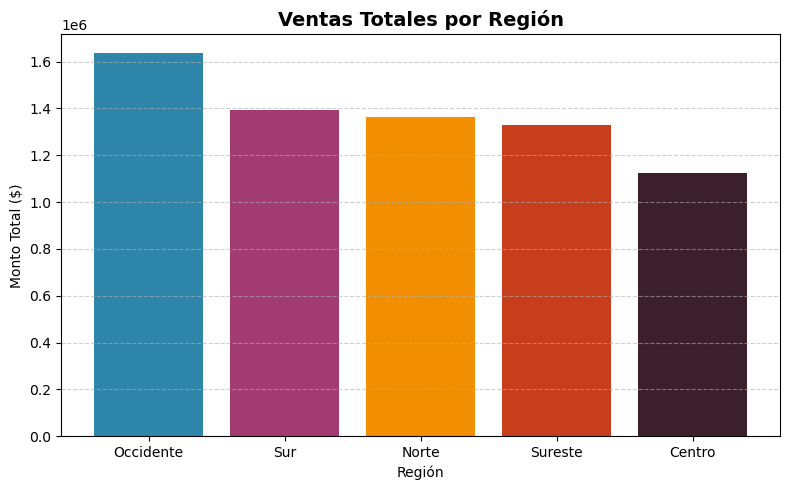

In [40]:
# Gráfico 1:Ventas totales por región
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    dfVentasRegion["region"],
    dfVentasRegion["total_ventas"],
    color=["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B"]
)
ax.set_title("Ventas Totales por Región", fontsize=14, fontweight="bold")
ax.set_xlabel("Región")
ax.set_ylabel("Monto Total ($)")
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

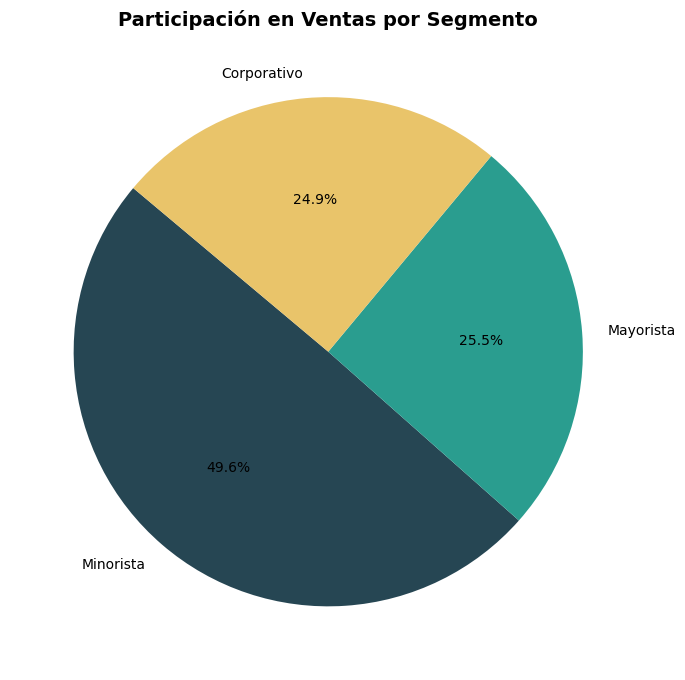

In [39]:
# Gráfico 2:  Participación por segmento de cliente
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    dfSegmento["total_ventas"],
    labels=dfSegmento["segmento"],
    autopct="%1.1f%%",
    startangle=140,
    colors=["#264653", "#2a9d8f", "#e9c46a"]
)
ax.set_title("Participación en Ventas por Segmento", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

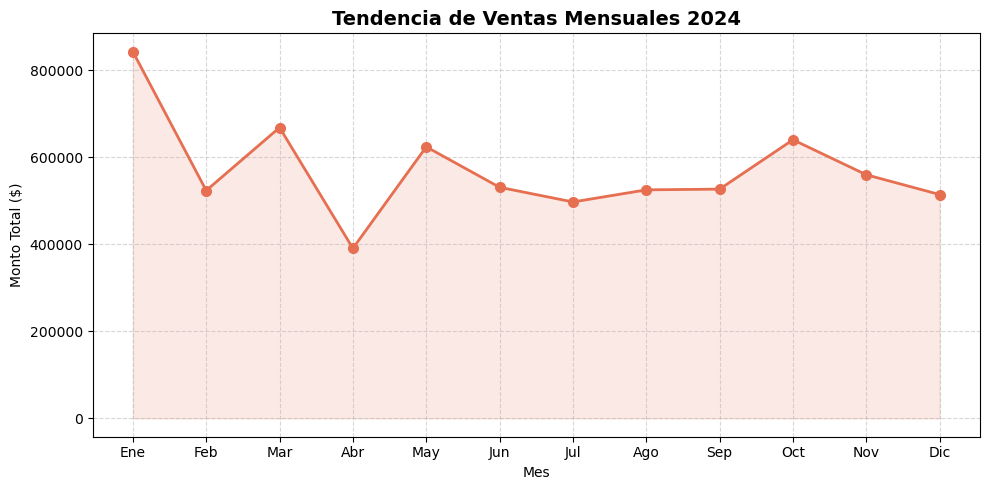

In [37]:
# Gráfico 3 – Tendencia de ventas mensuales
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    meses[:len(dfVentasMes)],
    dfVentasMes["ventas_mensuales"],
    marker="o",
    color="#E76F51",
    linewidth=2,
    markersize=7
)
ax.fill_between(
    meses[:len(dfVentasMes)],
    dfVentasMes["ventas_mensuales"],
    alpha=0.15,
    color="#E76F51"
)
ax.set_title("Tendencia de Ventas Mensuales 2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Monto Total ($)")
ax.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

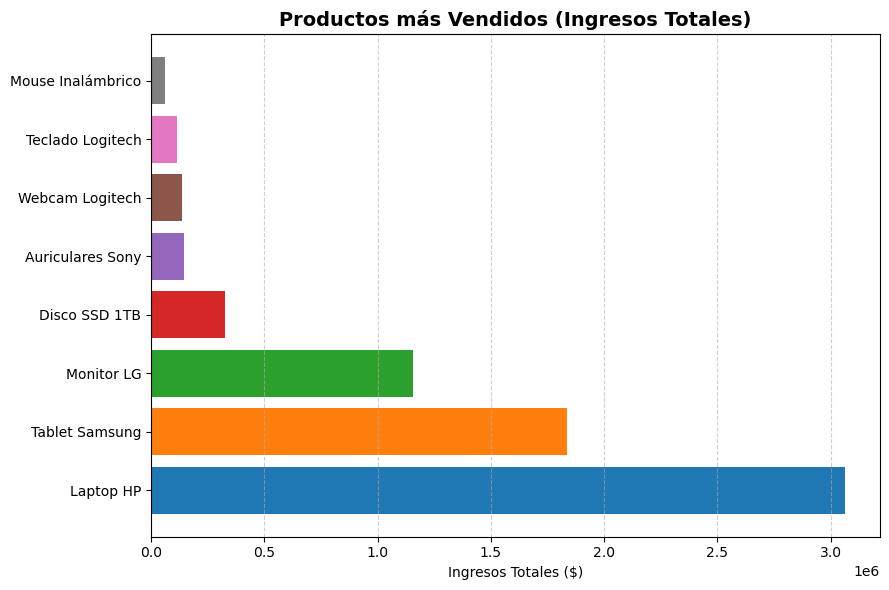

In [38]:
# Gráfico 4:Top productos por ingreso
fig, ax = plt.subplots(figsize=(9, 6))
colores = plt.cm.tab10.colors[:len(dfTopProductos)]
ax.barh(
    dfTopProductos["producto"],
    dfTopProductos["ingresos_totales"],
    color=colores
)
ax.set_title("Productos más Vendidos (Ingresos Totales)", fontsize=14, fontweight="bold")
ax.set_xlabel("Ingresos Totales ($)")
ax.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()